# State Capacity: model-recall (C-read) vs eRank — disentangling load vs horizon (notebook 3)

**Signal choice.** The recurrent SSM state is an associative memory: writes address `B_t`, reads address
`C_t`, and `value ≈ C·h`. So the *correct* linear read-out of the state is the model's **own C
projection** — i.e. the model's **recall** already IS the decodability measurement. (An external linear
probe with random key features can't align with `B/C` and reads at chance — that earlier attempt is
dropped; see note below.) We therefore take **model recall = C-read decodability = the state-capacity
signal**, and ask whether **eRank** tracks it.

**Two axes, separated by padding** (context length `L` controlled independently of load `N`):
- **Load axis** — `L` fixed, vary `N` (# pairs). Capacity stress. Does recall drop with `N`? Is eRank
  (pinned by `L`) flat across `N`?
- **Horizon axis** — `N` fixed (few pairs, placed early), pad with filler to length `L∈[32..4096]`.
  Does recall survive long distance? Does eRank saturate ~200 tok regardless?

**Hypothesis:** eRank does not track recall-capacity → **eRank ≠ capacity**; it is a state-spectrum /
memory-horizon diagnostic. *(Result, §6: even stronger — eRank is **anti-correlated** with recall on the
load axis and **decoupled** on the horizon axis.)*

Model: `mamba2-370m`. Shared code: `capacity_utils.py`.

## 0. Setup / imports

In [1]:
import os, sys, json, math
import numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0, os.getcwd())
from capacity_utils import DEVICE, load_bundle, S1_erank
RESULTS_DIR = os.path.join(os.getcwd(), "state_capacity_results"); os.makedirs(RESULTS_DIR, exist_ok=True)
torch.manual_seed(0); np.random.seed(0)
print("device:", DEVICE, "| results ->", RESULTS_DIR)

device: cuda | results -> /home/sohyung/SSM_Rank_Analysis/notebooks/state_capacity_results


## 1. Padded MQAR instances (control context length `L` independent of load `N`)
`N` key→value pairs at the **start**, then a low-information **filler** token repeated to reach context
length `L`, then the `N` keys as queries. State (for eRank) = after the length-`L` context; recall is
read at the query positions `L + i`.

In [2]:
KEY_OFF, VAL_OFF, VOCAB_V, FILLER = 1000, 5000, 64, 10
def make_padded_instance(N, L, seed):
    rng = np.random.default_rng(seed)
    assert L >= 2 * N, f"need L>=2N ({L}<{2*N})"
    keys = rng.choice(4000, size=N, replace=False) + KEY_OFF
    vcls = rng.integers(0, VOCAB_V, size=N)
    vals = vcls + VAL_OFF
    pairs = np.empty(2 * N, dtype=np.int64); pairs[0::2] = keys; pairs[1::2] = vals
    context = np.concatenate([pairs, np.full(L - 2 * N, FILLER, dtype=np.int64)])   # length L
    with_q = np.concatenate([context, keys])                                        # length L+N
    return {"keys": keys, "vcls": vcls, "qpos": L + np.arange(N),
            "context": torch.tensor(context, dtype=torch.long).unsqueeze(0),
            "with_queries": torch.tensor(with_q, dtype=torch.long).unsqueeze(0)}

## 2. Recall (model's C-read) and eRank helpers
**Note (dropped probe):** an external linear probe on `(random-projected state ⊗ random key-embedding)`
was tried and read at chance even where recall was 0.9 — because it ignores the model's `B/C` addressing.
The model's own read (below) is the theoretically correct state read-out, so we use it directly.

In [3]:
@torch.no_grad()
def model_recall(bundle, N, L, n_inst=40, seed=0):
    val_ids = torch.arange(VAL_OFF, VAL_OFF + VOCAB_V, device=DEVICE)
    hits = tot = 0
    for i in range(n_inst):
        inst = make_padded_instance(N, L, seed * 100000 + i)
        logits = bundle.logits(inst["with_queries"])[0]
        pred = logits[inst["qpos"]][:, val_ids].argmax(-1).cpu().numpy()
        hits += int((pred == inst["vcls"]).sum()); tot += N
    return hits / tot

def erank_ctx(bundle, N, L, n_inst=5, seed=0):
    return float(np.mean([S1_erank(bundle, make_padded_instance(N, L, seed * 100000 + i)["context"])["erank_mean"]
                          for i in range(n_inst)]))

CHANCE = 1.0 / VOCAB_V

## 2b. Load the model (once)

In [4]:
BUNDLE = load_bundle("mamba2-370m")
print("loaded", BUNDLE.name)

/data2/sohyung/conda-envs/sh_infocap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded mamba2-370m


## 3. LOAD axis — recall & eRank vs N at fixed context length `L`

In [5]:
L_FIXED = 512
N_LOAD = [2, 4, 8, 16, 32, 64, 128, 200]
load = []
for N in N_LOAD:
    load.append({"N": N, "recall": model_recall(BUNDLE, N, L_FIXED), "erank": erank_ctx(BUNDLE, N, L_FIXED)})
    print(f"[load] N={N:>3} L={L_FIXED} recall={load[-1]['recall']:.3f} eRank={load[-1]['erank']:.2f}")

[load] N=  2 L=512 recall=1.000 eRank=1.86


[load] N=  4 L=512 recall=0.975 eRank=2.09


[load] N=  8 L=512 recall=0.950 eRank=2.50


[load] N= 16 L=512 recall=0.933 eRank=3.08


[load] N= 32 L=512 recall=0.880 eRank=3.62


[load] N= 64 L=512 recall=0.765 eRank=4.00


[load] N=128 L=512 recall=0.602 eRank=4.14


[load] N=200 L=512 recall=0.431 eRank=4.38


## 4. HORIZON axis — recall & eRank vs context length `L` at fixed load `N`

In [6]:
N_FIXED = 8
L_HORIZON = [32, 64, 128, 256, 512, 1024, 2048, 4096]
horizon = []
for L in L_HORIZON:
    horizon.append({"L": L, "recall": model_recall(BUNDLE, N_FIXED, L, n_inst=30),
                    "erank": erank_ctx(BUNDLE, N_FIXED, L)})
    print(f"[horizon] N={N_FIXED} L={L:>4} recall={horizon[-1]['recall']:.3f} eRank={horizon[-1]['erank']:.2f}")
with open(os.path.join(RESULTS_DIR, "load_vs_horizon.json"), "w") as f:
    json.dump({"chance": CHANCE, "L_fixed": L_FIXED, "N_fixed": N_FIXED,
               "load": load, "horizon": horizon}, f, indent=2)

[horizon] N=8 L=  32 recall=0.921 eRank=3.43


[horizon] N=8 L=  64 recall=0.933 eRank=3.11


[horizon] N=8 L= 128 recall=0.942 eRank=2.95


[horizon] N=8 L= 256 recall=0.938 eRank=2.81


[horizon] N=8 L= 512 recall=0.933 eRank=2.50


[horizon] N=8 L=1024 recall=0.908 eRank=2.30


[horizon] N=8 L=2048 recall=0.846 eRank=2.08


[horizon] N=8 L=4096 recall=0.817 eRank=1.80


## 5. The formalization plot — eRank ≠ capacity

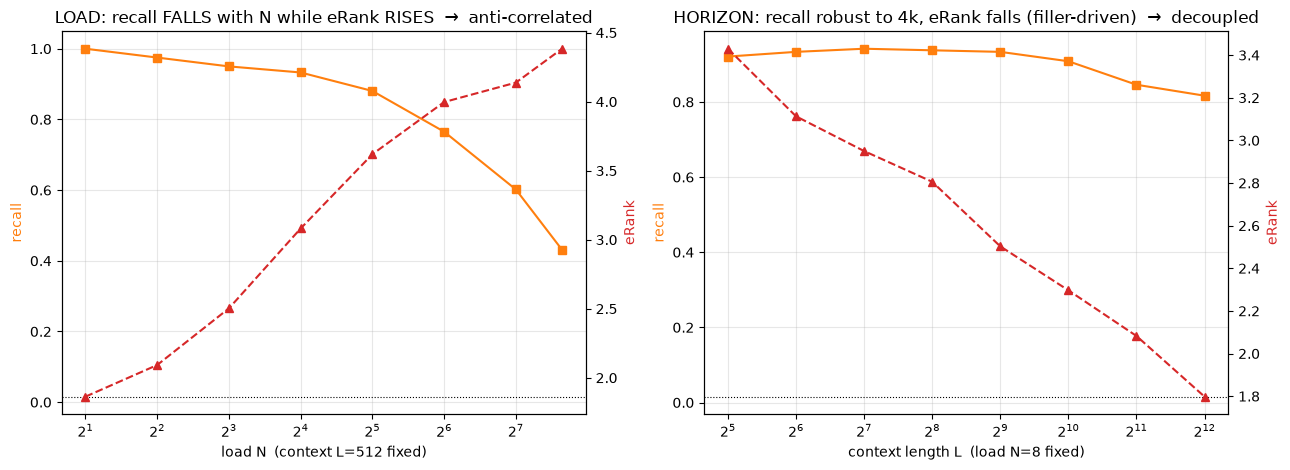

If eRank saturates on the HORIZON axis and is flat on the LOAD axis while recall moves on both, then eRank tracks the state's memory-horizon/spectrum, NOT capacity.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
# LOAD axis
a = ax[0]; ab = a.twinx()
Ns = [r["N"] for r in load]
a.plot(Ns, [r["recall"] for r in load], "s-", color="C1", label="model recall (capacity)")
a.axhline(CHANCE, color="k", ls=":", lw=.8)
ab.plot(Ns, [r["erank"] for r in load], "^--", color="C3", label="eRank")
a.set_xscale("log", base=2); a.set_xlabel(f"load N  (context L={L_FIXED} fixed)")
a.set_ylabel("recall", color="C1"); ab.set_ylabel("eRank", color="C3")
a.set_title("LOAD: recall FALLS with N while eRank RISES  →  anti-correlated"); a.grid(alpha=.3)
# HORIZON axis
b = ax[1]; bb = b.twinx()
Ls = [r["L"] for r in horizon]
b.plot(Ls, [r["recall"] for r in horizon], "s-", color="C1", label="model recall")
b.axhline(CHANCE, color="k", ls=":", lw=.8)
bb.plot(Ls, [r["erank"] for r in horizon], "^--", color="C3", label="eRank")
b.set_xscale("log", base=2); b.set_xlabel(f"context length L  (load N={N_FIXED} fixed)")
b.set_ylabel("recall", color="C1"); bb.set_ylabel("eRank", color="C3")
b.set_title("HORIZON: recall robust to 4k, eRank falls (filler-driven)  →  decoupled"); b.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "load_vs_horizon.png"), dpi=120); plt.show()
print("If eRank saturates on the HORIZON axis and is flat on the LOAD axis while recall moves on both, "
      "then eRank tracks the state's memory-horizon/spectrum, NOT capacity.")

## 6. Conclusion — eRank ≠ capacity (result)
Measured on mamba2-370m:
- **LOAD axis:** recall FALLS with N (1.00→0.43 for N=2→200 at L=512) while eRank **RISES** (1.9→4.4).
  They are **anti-correlated** — higher eRank is an *overload* symptom (more distinct content spread over
  more state directions with growing interference), **not** capacity headroom.
- **HORIZON axis:** recall is **robust to distance** (0.92→0.82 across L=32→4096, a 128× context increase),
  while eRank **falls** (3.4→1.8) because the repeated filler dominates the state's spectrum. **Decoupled.**
  (eRank's horizon trend is partly a filler artifact; the load-axis anti-correlation is filler-free and is
  the cleaner result.)

**Therefore:** the **capacity signal is model recall (the state's own C-read)**. **eRank tracks the
state's spectral spread / input composition, not retrievable capacity** — it can even move *opposite* to
capacity. Capacity is limited by **load** (recall halves ~N=128–200) and is **distance-robust** (0.82 at
4k) — confirming the "~200-tok eRank saturation ≠ 4k recall horizon" argument.

The earlier external random-feature probe was invalid (ignored `B/C` addressing) — the model's own read
is the correct state read-out.

**Next:** (B) a `B/C`-aware probe or recurrent-state SAE to size a *stored ≥ used* gap; then the deferred
**(3) SSC / memory-routing** reuse test on these recall-verified states.